In [1]:
setwd('/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/')
devtools::load_all('utils/modules/R/prstools')

i Loading PRStools

Loading required package: bigsnpr

Loading required package: bigstatsr

Loading required package: data.table

Loading required package: bigassertr



In [4]:
args <- list(
    path_bed_pred = "data/prs/hapmap/ukb_hapmap_500k_eur_chr21.bed",
    #path_ld_bed = "data/prs/hapmap/ld/unrel_eur_10k/short_ukb_hapmap_rand_10k_eur.bed",
    path_ld_bed = "data/prs/hapmap/ld/unrel_eur_10k/short_merged_ukb_hapmap_rand_10k_eur.bed",
    #path_ld_matrix = "data/prs/hapmap/ld/corr/ukb_eu_10k_ld_CAD_combined.rda",
    gwas = "data/prs/sumstat/ukb_hapmap_500k_eur_CAD_combined.txt.gz",
    #path_sumstat = "data/prs/hapmap/ld/corr/ukb_eu_10k_ld_CAD_combined_betas.txt.gz",
    chrom = '21'
)

In [5]:
#NCORES <- nb_cores()
#tmp <- tempfile(tmpdir = "data/tmp/tmp-data")
#on.exit(file.remove(paste0(tmp, ".sbk")), add = TRUE)

In [6]:

snp <- readRDS(args$path_ld_matrix)
df_beta <- fread(args$path_sumstat)
#ld_data <- load_bigsnp_from_bed(args$path_ld_bed)
#sumstats <- read_hail_sumstat(args$path_sumstat)

In [5]:
corr <- snp$corr

In [7]:
rds <- "data/prs/hapmap/ld/corr/"

ERROR: Error in corr[1:100, 1:100]: object of type 'S4' is not subsettable


In [7]:
#info_snp

In [8]:
#qc <- qc_binary_sumstat(ld_data$G, info_snp, NCORES)
#beta_cols <- c("beta", "beta_se", "n_eff", "_NUM_ID_")
#well_behaved_snps <- (!qc$is_bad)


In [9]:
#df_beta <- info_snp[well_behaved_snps,]

In [10]:
#snp <- calc_single_ld_matrix(ld_data$G, ld_data$POS2, df_beta, chr = paste0("chr",args$chrom),
#                                                  ncores = NCORES, tmp = tmp)

In [11]:
#snp$corr

In [12]:
length(snp$ld)

[1] 1105170

In [13]:
#length(snp$ld)

In [14]:
#length(c(df_beta$beta / df_beta$beta_se)^2)

In [15]:
#str(snp)

In [16]:
#nrow(df_beta)

In [17]:
#length(snp$ld)

In [18]:
ldsc <- with(df_beta, snp_ldsc(snp$ld, length(snp$ld), chi2 = (beta / beta_se)^2,
                                 sample_size = df_beta$n_eff, blocks = NULL))
ldsc_h2_est <- ldsc[["h2"]]

In [19]:
median(qchisq(1-df_beta$p,1)) / qchisq(0.5, 1)

[1] 1.10688

In [61]:
x <- load_bigsnp_from_bed(args$path_bed_pred)
nrow(x$map)

[1] 17827

In [21]:
#map <- x$map

In [22]:
#head(map)

In [23]:
#map$beta <- NA

In [24]:
#snp_match(map, df_beta[,c("chr", "pos", "a0","a1")])

In [25]:
# probably need to match SNPs in df_beta
#pred <- snp_subset(x$bigsnp, ind.row = 1:50, ind.col = 1:50)
#pred <- snp_attach(pred)
#beta_inf <- runif(50)
#final_pred_inf <- big_prodVec(pred$genotypes, beta_inf, ind.col = 1:50)
#final_pred_inf

In [26]:
# takes a long time...
#beta_inf <- snp_ldpred2_inf(snp$corr, df_beta, ldsc_h2_est)
beta_inf <- rnorm(nrow(df_beta), sd = 1e-3)

In [27]:
# beta_inf is a vector corresponding to df_beta SNPs
map <- x$map
map$beta <- NA


In [28]:
## ldpred2 inf model


In [29]:
df_beta$effects <- beta_inf
chr_beta <- df_beta[df_beta$chr == 'chr21',]
chr_beta <- chr_beta[,c("chr", "pos", "a0","a1", "effects")]

info_snp <- snp_match(map, chr_beta)
ind.chr <- which(info_snp$chr == "chr21")
ind.chr2 <- info_snp$`_NUM_ID_`[ind.chr]

pred <- snp_subset(x$bigsnp, ind.col = ind.chr2, ind.row = 1:1000)
pred <- snp_attach(pred)
dim(pred$genotypes); length(info_snp$beta_inf)

res <- big_prodVec(pred$genotypes, info_snp$effects)
print(head(res))

17,827 variants to be matched.

1,208 ambiguous SNPs have been removed.

14,711 variants have been matched; 0 were flipped and 0 were reversed.



[1]  1000 14711

[1] 0

[1]  0.01619929  0.01561064  0.03669304  0.07394026  0.09965220 -0.02462211


In [89]:
map <- x$map


In [90]:
map <- x$map
d <- df_beta
nrow(map); nrow(d)

[1] 17827

[1] 1105170

In [91]:
map$marker <- get_ldpred_marker(map)
d$marker <- get_ldpred_marker(d)

In [92]:
sum(d$marker %in% map$marker) == sum(map$marker %in% d$marker)

[1] TRUE

In [96]:
new_d <- d[match(map$marker, d$marker),]
new_d <- new_d[!(rowSums(is.na(new_d)) == ncol(new_d)),]

In [100]:
nrow(new_d)
nrow(df_beta[df_beta$chr == 'chr21',])

[1] 15906

[1] 15906

In [104]:
all(df_beta[df_beta$chr == 'chr21',]$pos == new_d$pos)

[1] TRUE

In [52]:
map <- data.frame(marker = letters[1:5])
d <- data.frame(marker = letters[20:1])
print(map); print(d)

# where are y in x if below is x and y
d[match(map$marker, d$marker),]

  marker
1      a
2      b
3      c
4      d
5      e
   marker
1       t
2       s
3       r
4       q
5       p
6       o
7       n
8       m
9       l
10      k
11      j
12      i
13      h
14      g
15      f
16      e
17      d
18      c
19      b
20      a


[1] "a" "b" "c" "d" "e"

In [50]:
pred <- snp_subset(x$bigsnp, ind.col = c(1,2), ind.row = 1:1000)
pred <- snp_attach(pred)
head(pred$map)
#head(chr_beta)

,chromosome,marker.ID,genetic.dist,physical.pos,allele1,allele2
,<chr>,<chr>,<dbl>,<int>,<chr>,<chr>
1,chr21,chr21:10510446:A:G,0,10510446,G,A
2,chr21,chr21:10592359:A:G,0,10592359,G,A


In [42]:
head(res)

[1] -0.02962951 -0.17127490 -0.06690907 -0.15184021  0.01631260  0.01589500

In [158]:
match_chromosome <- function(d, betas, chr){
    
    stopifnot(nrow(d) == length(prs_est)) 
    
    #d$marker <- paste0(
    #    df_beta$chr, 
    #    df_beta$pos, 
    #    df_beta$a0, 
    #    df_beta$a1, 
    #    collapse = ':')
    
    d$betas <- betas
    d_chr <- d[d$chr == chr,]
    d_chr <- d_chr[,c("chr", "pos", "a0","a1", "beta_inf")]
    ind.chr <- which(info_snp$chr == "chr21")
    ind.chr2 <- info_snp$`_NUM_ID_`[ind.chr]
    return(ind.chr2)
    
}

In [ ]:
#df_beta$marker.ID

In [156]:
pred$map$marker.ID

[1] "chr21:10510446:A:G"    "chr21:10592359:A:G"    "chr21:13222943:T:A"   
    [4] "chr21:13240882:G:T"    "chr21:13258267:A:G"    "chr21:13268079:G:A"   
    [7] "chr21:13270143:A:G"    "chr21:13277477:C:A"    "chr21:13293652:C:T"   
   [10] "chr21:13297610:G:A"    "chr21:13304586:A:G"    "chr21:13316504:T:C"   
   [13] "chr21:13317266:A:T"    "chr21:13384722:T:C"    "chr21:13390602:C:A"   
   [16] "chr21:13395248:T:C"    "chr21:13397219:T:C"    "chr21:13400911:G:T"   
   [19] "chr21:13403408:G:A"    "chr21:13408015:G:A"    "chr21:13413297:T:G"   
   [22] "chr21:13413312:G:T"    "chr21:13418249:A:C"    "chr21:13418412:A:T"   
   [25] "chr21:13423154:G:A"    "chr21:13423802:T:C"    "chr21:13426485:T:G"   
   [28] "chr21:13428532:C:T"    "chr21:13428821:G:A"    "chr21:13446612:T:C"   
   [31] "chr21:13448087:A:G"    "chr21:13448681:C:T"    "chr21:13450021:A:T"   
   [34] "chr21:13452182:T:C"    "chr21:13455377:T:C"    "chr21:13459286:G:A"   
   [37] "chr21:13459989:G:A"    "chr21:13464068:C:T"    "chr21:13466231:A:G"   
   [40] "chr21:13474973:A:G"    "chr21:13498350:A:G"    "chr21:13529599:T:G"   
   [43] "chr21:13543734:T:A"    "chr21:13558377:C:T"    "chr21:13559721:C:T"   
   [46] "chr21:13571018:G:T"    "chr21:13572794:T:C"    "chr21:13837028:A:G"   
   [49] "chr21:13841993:C:G"    "chr21:13843493:C:T"    "chr21:13908331:T:C"   
   [52] "chr21:13919595:T:A"    "chr21:13930991:G:A"    "chr21:13956012:T:C"   
   [55] "chr21:13959157:C:A"    "chr21:13959712:G:A"    "chr21:13964098:T:G"   
   [58] "chr21:13964300:A:G"    "chr21:13964764:T:C"    "chr21:13967777:G:T"   
   [61] "chr21:14000188:C:T"    "chr21:14003186:A:G"    "chr21:14006460:C:A"   
   [64] "chr21:14035713:A:G"    "chr21:14040078:G:A"    "chr21:14040510:A:G"   
   [67] "chr21:14040570:A:G"    "chr21:14044006:C:A"    "chr21:14052047:A:T"   
   [70] "chr21:14066323:A:G"    "chr21:14073147:A:G"    "chr21:14074891:T:G"   
   [73] "chr21:14076239:T:C"    "chr21:14076278:G:C"    "chr21:14084113:T:C"   
   [76] "chr21:14084307:C:G"    "chr21:14086358:C:T"    "chr21:14087115:C:T"   
   [79] "chr21:14091635:T:C"    "chr21:14096393:T:C"    "chr21:14101854:C:A"   
   [82] "chr21:14104569:C:T"    "chr21:14107216:C:T"    "chr21:14107357:C:G"   
   [85] "chr21:14108159:T:G"    "chr21:14109044:G:T"    "chr21:14110284:A:G"   
   [88] "chr21:14110397:T:C"    "chr21:14117522:T:G"    "chr21:14118929:T:C"   
   [91] "chr21:14118973:G:A"    "chr21:14121040:G:A"    "chr21:14122133:C:A"   
   [94] "chr21:14122634:C:T"    "chr21:14128050:C:G"    "chr21:14128105:G:A"   
   [97] "chr21:14129201:A:C"    "chr21:14131685:G:A"    "chr21:14143522:A:G"   
  [100] "chr21:14144009:A:C"    "chr21:14145782:G:T"    "chr21:14146031:T:C"   
  [103] "chr21:14151612:T:C"    "chr21:14158871:C:T"    "chr21:14162316:G:A"   
  [106] "chr21:14164227:T:C"    "chr21:14176418:C:T"    "chr21:14178114:T:C"   
  [109] "chr21:14180791:T:G"    "chr21:14181709:T:C"    "chr21:14186143:G:A"   
  [112] "chr21:14189460:G:A"    "chr21:14204215:A:C"    "chr21:14208506:G:T"   
  [115] "chr21:14215892:A:C"    "chr21:14219368:A:G"    "chr21:14222050:C:G"   
  [118] "chr21:14222144:T:C"    "chr21:14222174:T:C"    "chr21:14224451:T:G"   
  [121] "chr21:14227527:C:T"    "chr21:14227642:A:G"    "chr21:14228274:T:G"   
  [124] "chr21:14228884:G:A"    "chr21:14231268:C:T"    "chr21:14233807:C:A"   
  [127] "chr21:14237492:A:T"    "chr21:14238110:T:C"    "chr21:14239217:A:C"   
  [130] "chr21:14239323:G:C"    "chr21:14240878:T:A"    "chr21:14240919:G:A"   
  [133] "chr21:14241380:C:T"    "chr21:14241664:G:A"    "chr21:14242899:A:C"   
  [136] "chr21:14243179:T:C"    "chr21:14243534:G:A"    "chr21:14244308:C:G"   
  [139] "chr21:14244408:C:T"    "chr21:14244429:A:T"    "chr21:14244451:C:T"   
  [142] "chr21:14248477:T:C"    "chr21:14251120:T:C"    "chr21:14251896:C:T"   
  [145] "chr21:14252326:C:T"    "chr21:14254339:G:A"    "chr21:14255834:T:A"   
  [148] "chr21:14256347:G:C"    "chr21:14258491:T:G"    "chr21:14259820:G:T"   
  [1

In [121]:
# the two files are different in SNPs
nrow(df_beta[df_beta$chr == 'chr21',]); length(ind.chr); nrow(x$map); max(ind.chr); max(ind.chr2)

[1] 15906

[1] 14711

[1] 17827

[1] 14711

[1] 17827

[1] 14711

[1] 629742

In [68]:
#final_pred_inf <- big_prodVec(pred$G, beta_inf, ind.col = df_beta$`_NUM_ID_`)

[1] 16.129300 10.756512 17.599230  6.679773 14.263598 13.421582 12.373547
 [8] 19.828258 10.756512 18.064042 10.506854  8.285738 11.577538 13.421582
[15]  5.824517 13.421582 16.051564  5.229990  6.419045  6.419045  7.821066
[22] 14.024434  5.824517 16.871298 18.919298 20.424120 11.173421 10.161984
[29] 13.421582 19.568864 13.247225 12.566326  7.743198 12.827055 17.509391
[36]  9.937202 13.031568 17.759049 10.506854 12.566326 13.421582  8.440469
[43] 12.566326 10.756512  7.274301 16.903793  5.824517 10.343607 13.421582
[50] 19.394506

In [52]:
length(final_pred_inf)

[1] 176614

In [28]:
3e-3 == 3/1000

[1] TRUE

In [30]:
as.numeric("3e-4") - 1000

[1] -999.9997

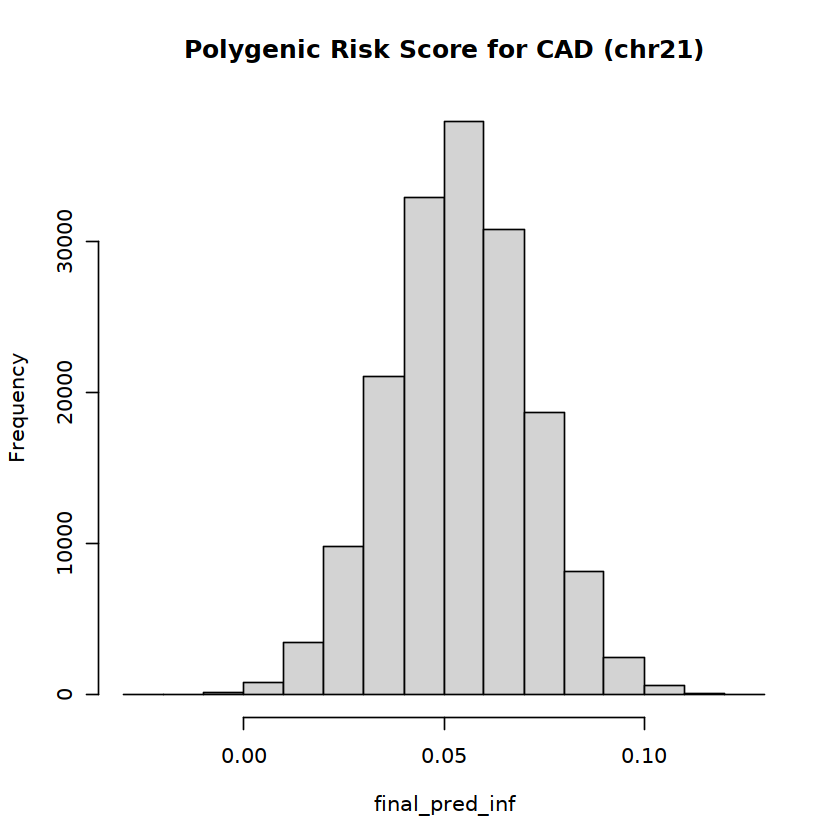

In [54]:
hist(final_pred_inf, main = "Polygenic Risk Score for CAD (chr21)")

In [32]:
sumstats <- data.frame(
  chr = 1,
  pos = c(86303, 86331, 162463, 752566, 755890, 758144),
  a0 = c("T", "G", "C", "A", "T", "G"),
  a1 = c("G", "A", "T", "G", "A", "A"),
  beta = c(-1.868, 0.250, -0.671, 2.112, 0.239, 1.272),
  p = c(0.860, 0.346, 0.900, 0.456, 0.776, 0.383)
)

info_snp <- data.frame(
  id = c("rs2949417", "rs115209712", "rs143399298", "rs3094315", "rs3115858"),
  chr = 1,
  pos = c(86303, 86331, 162463, 752566, 755890),
  a0 = c("T", "A", "G", "A", "T"),
  a1 = c("G", "G", "A", "G", "A")
)

print(sumstats)
print(info_snp)
snp_match(sumstats, info_snp)

  chr    pos a0 a1   beta     p
1   1  86303  T  G -1.868 0.860
2   1  86331  G  A  0.250 0.346
3   1 162463  C  T -0.671 0.900
4   1 752566  A  G  2.112 0.456
5   1 755890  T  A  0.239 0.776
6   1 758144  G  A  1.272 0.383
           id chr    pos a0 a1
1   rs2949417   1  86303  T  G
2 rs115209712   1  86331  A  G
3 rs143399298   1 162463  G  A
4   rs3094315   1 752566  A  G
5   rs3115858   1 755890  T  A


6 variants to be matched.

1 ambiguous SNPs have been removed.

4 variants have been matched; 1 were flipped and 1 were reversed.



chr,pos,a0,a1,beta,p,_NUM_ID_.ss,id,_NUM_ID_
<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<int>,<chr>,<int>
1,86303,T,G,-1.868,0.860,1,rs2949417,1
1,86331,A,G,-0.250,0.346,2,rs115209712,2
1,162463,G,A,-0.671,0.900,3,rs143399298,3
1,752566,A,G,2.112,0.456,4,rs3094315,4


In [12]:
spmat2 <- Matrix::Diagonal(4, 0:3)
spmat2[4, 2] <- 5
spmat2[1, 4] <- 6
spmat2[3, 4] <- 7
spmat2

# Stores all (i, x) for x != 0
(X2 <- as_SFBM(spmat2))
matrix(readBin(X2$sbk, what = double(), n = 100), 2)

4 x 4 sparse Matrix of class "dgCMatrix"
            
[1,] . . . 6
[2,] . 1 . .
[3,] . . 2 7
[4,] . 5 . 3

A Sparse Filebacked Big Matrix with 4 rows and 4 columns.

1,3,2,0,2,3
1,5,2,6,7,3


In [13]:
X2

A Sparse Filebacked Big Matrix with 4 rows and 4 columns.

# Setup matching using rds correlation matrix

## plan

### Perform QC on each chromosome
1. Load in .rds file containing SNPwise correlations for chromsome VALUE
2. Load in genotype file used to generated SNPwise correlation. Subset to chromosome VALUE.
3. Load in gwas summary stats. Subset to chromosome VALUE.
4. Match gwas and genotype file using match_snp.
5. Perform QC on GWAS using (4)
6. Subset SNPwise correlation matrix based on matching SNPs. (Ensure that Dims work)
7. Create tmp SFBM and append to correlation matrix.


### Perform QC genome-wide and then subset
* Should be the same if QC is only based on individuals variants (Rows). Check this.



In [35]:
lapply(args, file.exists)

$path_bed_pred
[1] FALSE

$path_ld_bed
[1] TRUE

$gwas
[1] TRUE

$chrom
[1] FALSE

In [21]:
d <- readRDS('data/prs/hapmap/ld/matrix/ld_matrix_unrel_eur_chr1.rda')

In [22]:
map <- fread('data/prs/hapmap/ld/matrix/ld_matrix_unrel_eur_chr1txt.gz')

In [23]:
nrow(map); dim(d)

[1] 96396

[1] 96396 96396

In [32]:
bed <- load_bigsnp_from_bed(args$path_ld_bed) # This was used to produce map, so map is a subset of bed$map..

In [36]:
gwas <- read_hail_sumstat(args$gwas)

In [43]:
#info_snp <- snp_match(gwas, bed$map, join_by_pos = TRUE, strand_flip = FALSE) # matching all chroms
info_snp <- snp_match(gwas, map, join_by_pos = TRUE, strand_flip = FALSE) # matching only chr1
nrow(info_snp) # not all snps matched (expected to find 96396)

1,167,580 variants to be matched.

Some duplicates were removed.

96,201 variants have been matched; 0 were flipped and 0 were reversed.



[1] 96201

In [53]:
qc <- qc_binary_sumstat(bed$G, info_snp, NCORES)
well_behaved_snps <- (!qc$is_bad)
df_beta <- info_snp[well_behaved_snps, ]

In [44]:
head(info_snp)

,chr,pos,a0,a1,rsid.ss,n_eff,beta_se,p,beta,INFO,MAF,_NUM_ID_.ss,rsid,_NUM_ID_
,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<int>,<chr>,<int>
1,chr1,817341,A,G,chr1:817341_A_G,381192,0.0117950,0.18683,-0.01557000,NA,0.16040,1,chr1:817341:A:G,1
2,chr1,818802,A,G,chr1:818802_A_G,381192,0.0125710,0.22785,-0.01515900,NA,0.13027,2,chr1:818802:A:G,2
3,chr1,818954,T,C,chr1:818954_T_C,381192,0.0125640,0.22805,-0.01514400,NA,0.13057,3,chr1:818954:T:C,3
4,chr1,825532,C,T,chr1:825532_C_T,381192,0.0117060,0.25218,-0.01340500,NA,0.16099,4,chr1:825532:C:T,4
5,chr1,833068,G,A,chr1:833068_G_A,381192,0.0137450,0.84022,0.00277110,NA,0.10605,5,chr1:833068:G:A,5
6,chr1,841166,A,G,chr1:841166_A_G,381192,0.0097558,0.94298,0.00069777,NA,0.25808,6,chr1:841166:A:G,6


In [48]:
max(info_snp$`_NUM_ID_`); unique(length(info_snp$`_NUM_ID_`)); any(is.na(info_snp$`_NUM_ID_`))

[1] 96396

[1] 96201

[1] FALSE

In [52]:
indicies <- info_snp$`_NUM_ID_`
dim(d[indicies, indicies])

[1] 96201 96201

# setup matching

In [216]:
# load data
snp <- readRDS(args$path_ld_matrix)

In [14]:
gwas <- fread(args$path_sumstat)
bed <- load_bigsnp_from_bed(args$path_bed_pred)

In [15]:
bed_map <- bed$map
bed_map$marker <- get_ldpred_marker(bed_map)
bed_map$index <- 1:nrow(bed_map)
gwas$marker <- get_ldpred_marker(gwas)
gwas$index <- 1:nrow(gwas)

In [16]:
stopifnot(sum(gwas$marker %in% bed_map$marker) == sum(bed_map$marker %in% gwas$marker))

In [17]:
# remove any bed markers not in gwas
bed_map <- bed_map[bed_map$marker %in% gwas$marker,]

In [18]:
# match gwas betas with bed map
indicies <- match(bed_map$marker, gwas$marker)
gwas_matched <- gwas[indicies,]
gwas_matched <- gwas_matched[!(rowSums(is.na(gwas_matched)) == ncol(gwas_matched)),]

In [19]:
stopifnot(all(gwas_matched$pos == bed_map$pos))

In [20]:
ld_pred_inf <- beta_inf[indicies]

In [21]:
pred <- snp_subset(bed$bigsnp, ind.col = bed_map$index, ind.row = 1:1000)
pred <- snp_attach(pred)

In [22]:
dim(pred$genotypes)

[1]  1000 15906

In [6]:
res <- big_prodVec(pred$genotypes, ld_pred_inf)

ERROR: Error in as.list.environment(parent.frame()): object 'pred' not found


In [9]:
get_ldpred_marker <- function(d){
    return(
        paste(
        d$chr, 
        d$pos, 
        d$a0, 
        d$a1, 
        sep = ':')
    )
}

In [80]:
predict_prs <- function(obj, gwas, effects, ind_row = NULL, ncores = 1){
    
    # assume that effect index correspond to gwas index
    stopifnot(length(effects) == nrow(gwas))
    
    # add indexes used for later subsetting
    bed_map <- obj$map
    bed_map$marker <- get_ldpred_marker(bed_map)
    bed_map$index <- 1:nrow(bed_map)
    gwas$marker <- get_ldpred_marker(gwas)
    gwas$index <- 1:nrow(gwas)
    
    # check that all markers are contained in one another
    stopifnot(sum(gwas$marker %in% bed_map$marker) == sum(bed_map$marker %in% gwas$marker))
    
    # remove any bed markers not in gwas (assuming
    # that the GWAS has already been qced before)
    bed_map <- bed_map[bed_map$marker %in% gwas$marker,]
    
    # match gwas betas with bed map
    indicies <- match(bed_map$marker, gwas$marker)
    gwas_matched <- gwas[indicies,]
    gwas_matched <- gwas_matched[!(rowSums(is.na(gwas_matched)) == ncol(gwas_matched)),]
    
    # check that all positions match
    stopifnot(all(gwas_matched$pos == bed_map$pos))
    
    # get subset of effects corresponding to bed_map
    ld_pred_effects <- effects[indicies]
    
    # subset bigsnp to get the right genotypes
    samples <- obj$bigsnp$fam$sample.ID
    if (is.null(ind_row)) ind_row <- 1:length(samples)
    subsetted_bigsnp <- snp_subset(obj$bigsnp, ind.col = bed_map$index, ind.row = ind_row)
    subsetted_bigsnp <- snp_attach(subsetted_bigsnp)
    genotypes <- subsetted_bigsnp$genotypes     
    stopifnot(dim(genotypes)[2] == length(ld_pred_effects))

    # Get PRS
    dot_product <- big_prodVec(genotypes, ld_pred_effects, ncores = ncores)
    return(list(prs = dot_product, sid =  samples[ind_row]))
}

In [81]:
snp <- readRDS(args$path_ld_matrix)

In [82]:
gwas <- fread(args$path_sumstat)
bigsnp <- load_bigsnp_from_bed(args$path_bed_pred)
beta_inf <- rnorm(nrow(gwas), sd = 1e-3)
#beta_inf <- snp_ldpred2_inf(snp$corr, df_beta, ldsc_h2_est)


In [85]:
result <- predict_prs(bigsnp, gwas, beta_inf)

In [86]:
?big_prodVec

Warning message in seq_len(head.end.idx):
"first element used of 'length.out' argument"
ERROR while rich displaying an object: Error in seq_len(head.end.idx): argument must be coercible to non-negative integer

Traceback:
1. FUN(X[[i]], ...)
2. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
3. tryCatchList(expr, classes, parentenv, handlers)
4. tryCatchOne(expr, names, parentenv, handlers[[1L]])
5. doTryCatch(return(expr), name, parentenv, handler)
6. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_conte

In [12]:
# load data
snp <- readRDS(args$path_ld_matrix)
gwas <- fread(args$path_sumstat)
bed <- load_bigsnp_from_bed(args$path_bed_pred)

In [13]:
bed_map <- bed$map
bed_map$marker <- get_ldpred_marker(bed_map)
bed_map$index <- 1:nrow(bed_map)
gwas$marker <- get_ldpred_marker(gwas)
gwas$index <- 1:nrow(gwas)

In [14]:
# remove any bed markers not in gwas
bed_map <- bed_map[bed_map$marker %in% gwas$marker,]

In [15]:
# match gwas betas with bed map
indicies <- match(bed_map$marker, gwas$marker)
gwas_matched <- gwas[indicies,]
gwas_matched <- gwas_matched[!(rowSums(is.na(gwas_matched)) == ncol(gwas_matched)),]

In [ ]:
    
# subset bigsnp to get the right genotypes
subsetted_bigsnp <- snp_subset(obj$bigsnp, ind.col = bed_map$index, ind.row = 1:100)
subsetted_bigsnp <- snp_attach(subsetted_bigsnp)

In [17]:
ldsc <- with(gwas, snp_ldsc(snp$ld, length(snp$ld), chi2 = (beta / beta_se)^2,
                                 sample_size = gwas$n_eff, blocks = NULL))
ldsc_h2_est <- ldsc[["h2"]]

In [ ]:
# ldpred2 auto model
multi_auto <- snp_ldpred2_auto(
   snp$corr,
   gwas,
   h2_init = ldsc_h2_est,
   vec_p_init = seq_log(1e-4, 0.5, 30),
   ncores = 1)

ld_pred_effects <- multi_auto[indicies]


 # run first estimates
  #beta_auto <- sapply(multi_auto, function(auto) auto$beta_est)
  #pred_auto <- big_prodMat(
  #    genotypes,
  #    beta_auto,
  #    ind.col = gwas[["_NUM_ID_"]],
  #    ncores = NCORES)

  # quality controls on chains
  #sc <- apply(pred_auto, 2, sd)
  #keep <- abs(sc - median(sc)) < 3 * mad(sc)
  #final_beta_auto <- rowMeans(beta_auto[, keep])

  # run final estimates

  #final_pred_auto <- big_prodVec(
  #    genotypes, final_beta_auto,
  #    ind.col = gwas[["_NUM_ID_"]],
  #    ncores = NCORES)

# Debug chr7

In [123]:
args <- list(
    gwas = "data/prs/hapmap/ld/corr/ukb_eu_10k_ld_CAD_combined_betas.txt.gz",
    ld_matrix = "data/prs/hapmap/ld/corr/ukb_eu_10k_ld_CAD_combined.rda",
    pred = "data/prs/hapmap/ukb_hapmap_500k_eur_chr7.bed"
)

In [124]:
print(args)
stopifnot(file.exists(args$pred))
stopifnot(file.exists(args$ld_matrix))
stopifnot(file.exists(args$gwas))


$gwas
[1] "data/prs/hapmap/ld/corr/ukb_eu_10k_ld_CAD_combined_betas.txt.gz"

$ld_matrix
[1] "data/prs/hapmap/ld/corr/ukb_eu_10k_ld_CAD_combined.rda"

$pred
[1] "data/prs/hapmap/ukb_hapmap_500k_eur_chr7.bed"



In [125]:
# Load LD matrix and qced betas
snp <- readRDS(args$ld_matrix)
gwas <- fread(args$gwas)

# check that LD and GWAS data was generated simultanously
stopifnot(length(snp$ld) == nrow(gwas))

In [126]:
pred <- load_bigsnp_from_bed(args$pred)

Warning message in load_bigsnp_from_bed(args$pred):
"NAs introduced by coercion"


ERROR: Error: 'infos.chr' should have only positive values.


In [128]:
bed <- args$pred

In [133]:
# Read from bed/bim/fam, it generates .bk and .rds files.
#tmp <- tempfile(tmpdir = "data/tmp/tmp-data")
#on.exit(file.remove(paste0(tmp, ".sbk")), add = TRUE)

if (!file.exists.ext(bed, '.bk')) snp_readBed(bed)
basename <- tools::file_path_sans_ext(bed)
rds <- paste0(basename,'.rds')
big_snp <- snp_attach(rds)

In [134]:
# extract the SNP information from the genotype
map <- big_snp$map[-3]
names(map) <- c("chr", "rsid", "pos", "a1", "a0")



In [135]:
# remove non-autosomes (e.g. chr8_KI270821v1_alt)
autosomes <- paste0('chr',1:22)
big_snp$map <- big_snp$map[big_snp$map$chr %in% autosomes,]
G <- big_snp$genotypes



In [136]:
# Rename the data structures
CHR <- as.numeric(gsub('chr','',map$chr))
POS <- map$pos

Warning message in eval(expr, envir, enclos):
"NAs introduced by coercion"


In [138]:
map$chr

[1] "chr7"                "chr7"                "chr7"               
    [4] "chr7"                "chr7"                "chr7"               
    [7] "chr7"                "chr7"                "chr7"               
   [10] "chr7"                "chr7"                "chr7"               
   [13] "chr7"                "chr7"                "chr7"               
   [16] "chr7"                "chr7"                "chr7"               
   [19] "chr7"                "chr7"                "chr7"               
   [22] "chr7"                "chr7"                "chr7"               
   [25] "chr7"                "chr7"                "chr7"               
   [28] "chr7"                "chr7"                "chr7"               
   [31] "chr7"                "chr7"                "chr7"               
   [34] "chr7"                "chr7"                "chr7"               
   [37] "chr7"                "chr7"                "chr7"               
   [40] "chr7"                "chr7"                "chr7"               
   [43] "chr7"                "chr7"                "chr7"               
   [46] "chr7"                "chr7"                "chr7"               
   [49] "chr7"                "chr7"                "chr7"               
   [52] "chr7"                "chr7"                "chr7"               
   [55] "chr7"                "chr7"                "chr7"               
   [58] "chr7"                "chr7"                "chr7"               
   [61] "chr7"                "chr7"                "chr7"               
   [64] "chr7"                "chr7"                "chr7"               
   [67] "chr7"                "chr7"                "chr7"               
   [70] "chr7"                "chr7"                "chr7"               
   [73] "chr7"                "chr7"                "chr7"               
   [76] "chr7"                "chr7"                "chr7"               
   [79] "chr7"                "chr7"                "chr7"               
   [82] "chr7"                "chr7"                "chr7"               
   [85] "chr7"                "chr7"                "chr7"               
   [88] "chr7"                "chr7"                "chr7"               
   [91] "chr7"                "chr7"                "chr7"               
   [94] "chr7"                "chr7"                "chr7"               
   [97] "chr7"                "chr7"                "chr7"               
  [100] "chr7"                "chr7"                "chr7"               
  [103] "chr7"                "chr7"                "chr7"               
  [106] "chr7"                "chr7"                "chr7"               
  [109] "chr7"                "chr7"                "chr7"               
  [112] "chr7"                "chr7"                "chr7"               
  [115] "chr7"                "chr7"                "chr7"               
  [118] "chr7"                "chr7"                "chr7"               
  [121] "chr7"                "chr7"                "chr7"               
  [124] "chr7"                "chr7"                "chr7"               
  [127] "chr7"                "chr7"                "chr7"               
  [130] "chr7"                "chr7"                "chr7"               
  [133] "chr7"                "chr7"                "chr7"               
  [136] "chr7"                "chr7"                "chr7"               
  [139] "chr7"                "chr7"                "chr7"               
  [142] "chr7"                "chr7"                "chr7"               
  [145] "chr7"                "chr7"                "chr7"               
  [148] "chr7"                "chr7"                "chr7"               
  [151] "chr7"                "chr7"                "chr7"               
  [154] "chr7"                "chr7"                "chr7"               
  [157] "chr7"                "chr7"                "chr7"               
  [160] "chr7"                "chr7"                "chr7"               
  [163] 

In [ ]:
# get the CM information from hapmap SNPs
POS2 <- snp_as_genetic_position(CHR, POS, mapdir = "data/prs/1000-genomes-genetic-maps",genetic_map = 'hapmap')


In [115]:
corr <- readRDS('data/prs/hapmap/ld/corr//ld_matrix_chrchr1.rda')

In [120]:
dim(corr)

[1] 97826 97826

In [ ]:
fread('data/prs/hapmap/ld/corr/') # read in matrix

# Test PRS

In [2]:
library(ggplot2)

In [3]:
files <- list.files('data/prs/scores/test/', pattern = '.txt.gz', full.names = TRUE)
print(length(files))
d <- do.call(rbind, lapply(1:22, function(x) {
    f <- files[grepl(paste0("chr",x,".txt.gz"),files)]
    print(f)
    if (length(f)){
        d <- fread(f)
        d$chr <- paste0("chr",x)
        return(d)
    }
  
}))

[1] 24
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr1.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr2.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr3.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr4.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr5.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr6.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr7.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr8.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr9.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr10.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr11.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr12.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr13.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr14.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr15.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr16.txt.gz"
[1] "data/

In [195]:
pgs <- fread('data/prs/scores/test/test_ukb_by_chrom_500k_pgs.txt.gz')
pgs_phenotypes <- colnames(pgs)[-1]
phenotypes <- fread('data/phenotypes/curated_phenotypes.tsv')

In [196]:
d <- do.call(rbind,lapply(pgs_phenotypes, function(phenotype){
    df <- p[,c('eid',phenotype), with = FALSE]
    colnames(df) <- c('sid','phenotype')
    mrg <- merge(pgs, df, all.x = TRUE)
    colnames(mrg) <- c('sid','pgs','is_case')
    mrg$phenotype <- phenotype
    return(mrg)
}))


In [54]:
pct <- 0.01
lower_bound <- quantile(d$pgs, pct)
upper_bound <- quantile(d$pgs, 1 - pct)
d$category <- ifelse(d$pgs >= upper_bound, paste0('Top ',pct*100,'% risk'),
                    ifelse(d$pgs <= lower_bound, paste0('Bottom ',pct*100,'% risk'), NA))

#samples_upper <- M$sid[M_pheno$pgs >= upper_bound]
#samples_lower <- M$sid[M$pgs <= lower_bound]

In [147]:
write(paste('* TRUE/FALSE indicate',phenotype, 'status'),stdout())

tbl <- table(d$is_case, d$category)
tbl

* TRUE/FALSE indicate CAD_combined status


       
        Bottom 1% risk Top 1% risk
  FALSE           3806         987
  TRUE               7        2826

In [ ]:
calc_or <- function(M){
    
}

In [ ]:
OR 

In [192]:
dt <- d
M <- do.call(rbind, lapply(seq(0.005,0.20, by = 0.005), function(pct){

    lower_bound <- quantile(dt$pgs, pct)
    upper_bound <- quantile(dt$pgs, 1 - pct)
    dt$category <- ifelse(dt$pgs >= upper_bound, 'top',
                    ifelse(dt$pgs <= lower_bound, 'bottom', NA))

    bottom_false <- sum(dt$category == 'bottom' & !dt$is_case, na.rm = TRUE)
    bottom_true <- sum(dt$category == 'bottom' & dt$is_case, na.rm = TRUE) 
    top_false <- sum(dt$category == 'top' & !dt$is_case, na.rm = TRUE) 
    top_true <- sum(dt$category == 'top' & dt$is_case, na.rm = TRUE)
    
    lh <- (bottom_false / bottom_true) / (top_false / top_true)
    logor <- log((bottom_false*top_true) / (bottom_true*top_false))
    se_log_or <- sqrt((1/bottom_true) + (1/bottom_false) + (1/top_false) + (1/top_true))
    ci <- qnorm(0.975)*se_log_or
    
    return(data.frame(
        pct = pct,
        bottom_false = bottom_false, 
        bottom_true = bottom_true,
        top_false = top_false,
        top_true = top_true,
        bottom_case_frac = bottom_true / (bottom_false + bottom_true),
        top_case_frac = top_true / (top_true + top_false),
        lh = lh,
        logor = logor,
        logor_ci_upper = logor + ci,
        logor_ci_lower = logor - ci
        
        
    ))
}))

In [193]:
tail(M)

,pct,bottom_false,bottom_true,top_false,top_true,bottom_case_frac,top_case_frac,lh,logor,logor_ci_upper,logor_ci_lower
,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
35,0.175,66227,484,47058,19647,0.007255175,0.2945356,57.12846,4.045302,4.136253,3.954352
36,0.180,68102,515,48711,19900,0.007505429,0.2900410,54.02300,3.989410,4.077656,3.901163
37,0.185,69985,538,50363,20154,0.007628717,0.2858034,52.05619,3.952324,4.038707,3.865941
38,0.190,71869,561,52033,20390,0.007745409,0.2815404,50.20155,3.916046,4.000682,3.831410
39,0.195,73742,594,53724,20605,0.007990745,0.2772135,47.61379,3.863122,3.945446,3.780799
40,0.200,75617,625,55378,20857,0.008197581,0.2735882,45.56737,3.819192,3.899508,3.738876


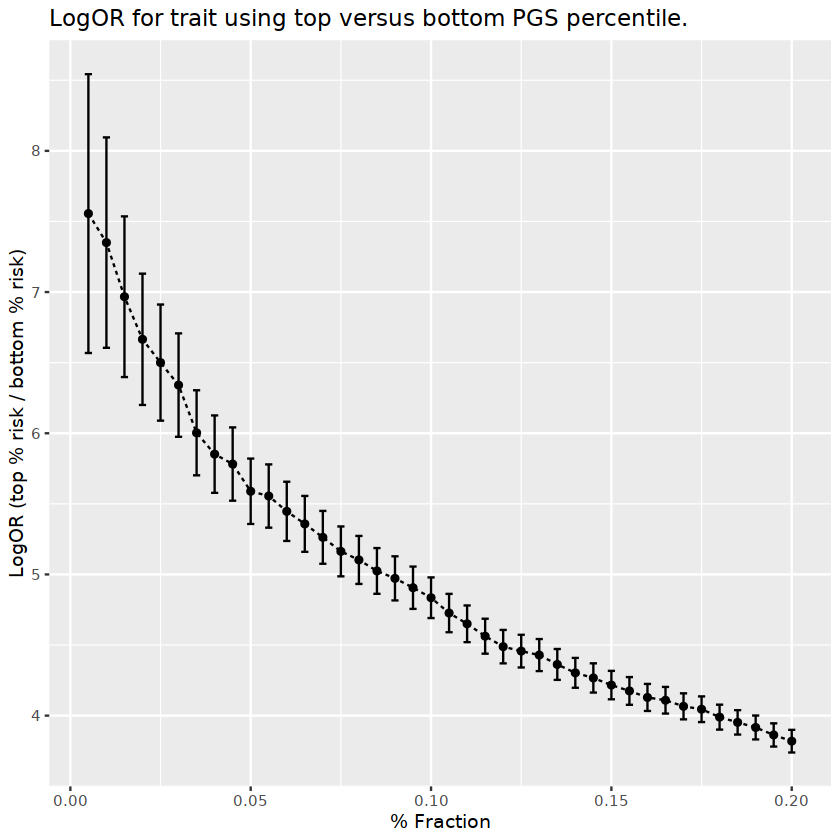

In [194]:
ggplot(M, aes(x=pct, y = logor, ymax = logor_ci_upper, ymin = logor_ci_lower)) +
    geom_point() +
    geom_errorbar(width = 2e-3) +
    geom_line(linetype = 'dashed') +
    xlab('% Fraction') + 
    ylab('LogOR (top % risk / bottom % risk)') +
    ggtitle('LogOR for trait using top versus bottom PGS percentile.')

In [15]:
#pheno_true_line <- median(d$pgs[M_pheno$phenotype], na.rm = TRUE)
#pheno_false_line <- median(d$pgs[!M_pheno$phenotype], na.rm = TRUE)

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



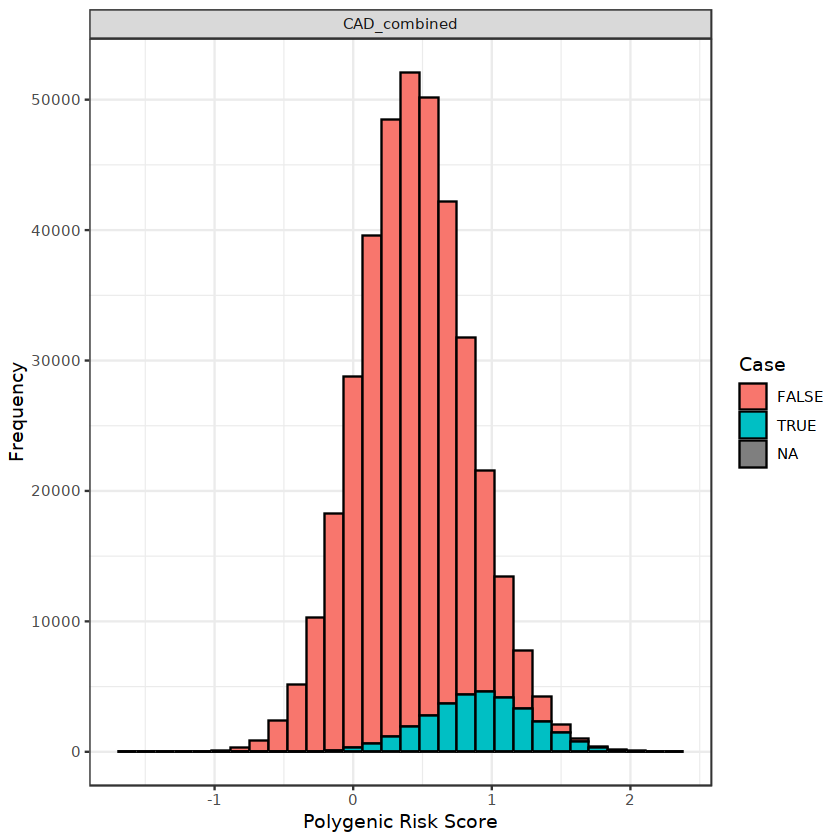

In [203]:
ggplot(d, aes(x=pgs, fill=is_case)) +
    geom_histogram(color = 'black') +
    #geom_vline(xintercept=pheno_true_line, linetype = 'dashed') +
    #geom_vline(xintercept=pheno_false_line, linetype = 'dashed') +
    labs(fill="Case") + 
    xlab('Polygenic Risk Score') +
    ylab("Frequency") +
    theme_bw() +
    facet_wrap(~phenotype)

In [60]:
args <- list(
    path_phenos = "data/phenotypes/curated_phenotypes_binary_header.tsv",
    in_dir = "data/prs/scores",
    pred =  "data/prs/hapmap/ukb_500k/ukb_hapmap_500k_eur_chr21.bed"
)

In [61]:
phenos <- unlist(strsplit(readLines(args$path_phenos), split = "\\s+", perl = TRUE))
files <- list.files(args$in_dir, pattern = '.txt.gz', full.names = TRUE)
files

[1] "data/prs/scores/prs_AD_combined_chr12_test.txt.gz"
 [2] "data/prs/scores/prs_CAD_combined_chr1.txt.gz"     
 [3] "data/prs/scores/prs_CAD_combined_chr10.txt.gz"    
 [4] "data/prs/scores/prs_CAD_combined_chr11.txt.gz"    
 [5] "data/prs/scores/prs_CAD_combined_chr12.txt.gz"    
 [6] "data/prs/scores/prs_CAD_combined_chr13.txt.gz"    
 [7] "data/prs/scores/prs_CAD_combined_chr14.txt.gz"    
 [8] "data/prs/scores/prs_CAD_combined_chr15.txt.gz"    
 [9] "data/prs/scores/prs_CAD_combined_chr16.txt.gz"    
[10] "data/prs/scores/prs_CAD_combined_chr17.txt.gz"    
[11] "data/prs/scores/prs_CAD_combined_chr18.txt.gz"    
[12] "data/prs/scores/prs_CAD_combined_chr2.txt.gz"     
[13] "data/prs/scores/prs_CAD_combined_chr20.txt.gz"    
[14] "data/prs/scores/prs_CAD_combined_chr21.txt.gz"    
[15] "data/prs/scores/prs_CAD_combined_chr22.txt.gz"    
[16] "data/prs/scores/prs_CAD_combined_chr3.txt.gz"     
[17] "data/prs/scores/prs_CAD_combined_chr4.txt.gz"     
[18] "data/prs/scores/prs_CAD_combined_chr5.txt.gz"     
[19] "data/prs/scores/prs_CAD_combined_chr6.txt.gz"     
[20] "data/prs/scores/prs_CAD_combined_chr9.txt.gz"

In [65]:
# get the right files
pheno_list <- lapply(phenos, function(pheno){
    
    files <- list.files(args$in_dir, pattern = '.txt.gz', full.names = TRUE)
    regex <- paste0('_',pheno,'_')
    files <- files[grepl(regex, files)]
    
    if (length(files) > 0) {
        
        write(paste0('Aggregating ',pheno,'..'),stdout())
        count = 0
        # append into a single 2 x n matrix
        d <- do.call(rbind, lapply(1:22, function(x) {
            f <- files[grepl(paste0("chr",x,".txt.gz"),files)]
            if (length(f)){
                d <- fread(f)
                d$chr <- paste0("chr",x)
                return(d)
            } 
        }))

        # Aggregate PRS into a n x 22 matrix (n = samples)
        M <- dcast(sid ~ chr, value.var = "prs", data = d)

        # sum up PRS score
        M[is.na(M)] <- 0
        M <- data.table(
            sid = M$sid, 
            pgs = rowSums(M[,2:ncol(M)]),
            phenotype = pheno
        )
        
        return(M)
        
    } else {
        
        return(NULL)
    }
    
})

# combine into single matrix
d <- do.call(rbind, pheno_list)
M <- dcast(sid ~ phenotype, value.var = "pgs", data = d)
fwrite(M, paste0(args$out_prefix, '.txt.gz'))


Aggregating CAD_combined..
Aggregating AD_combined..


sid,AD_combined,CAD_combined
<int>,<dbl>,<dbl>
1000028,0.0100868246,-0.019095106
1000034,0.0228171650,0.043152422
1000087,0.0158972028,0.127600711
1000118,0.0086467800,0.049282879
1000120,0.0000000000,0.029542824
1000162,0.0121252005,0.098599573
1000171,-0.0091025097,0.006515835
1000196,0.0004503702,0.084415562
1000254,-0.0109947870,0.002897558


In [53]:
file.exists(args$pred)

[1] TRUE

In [54]:
pred <- load_bigsnp_from_bed(args$pred)

ERROR: Error in load_bigsnp_from_bed(args$pred): data/prs/hapmap/ukb_500k/ukb_hapmap_500k_eur_chr21.rds was not found? Check snp_readBED?


In [59]:
bed <- args$pred
#snp_readBed(bed)
#if (!file.exists.ext(bed, '.bk')) 
#basename <- tools::file_path_sans_ext(bed)
#rds <- paste0(basename,'.rds')
#if (!file.exists(rds)) stop(paste(rds, "was not found? Check snp_readBED?"))
big_snp <- snp_attach(rds)

ERROR: Error: File 'data/prs/hapmap/ukb_500k/ukb_hapmap_500k_eur_chr21.rds' doesn't exist.


In [74]:
main <- function(args){

  print(args)
  stopifnot(dir.exists(args$in_dir))
  stopifnot(dir.exists(args$out_dir))

  phenos <- unlist(strsplit(readLines(args$path_phenos), split = "\\s+", perl = TRUE))
  files <- list.files(args$in_dir, pattern = '.txt.gz', full.names = TRUE)

   pheno_list <- lapply(phenos, function(pheno){

      if (is.null(args$grep)){
         regex <- paste0('_',pheno,'_')
         files_regex <- files[grepl(regex, files)]
      } else {
         files_regex <- files[grepl(args$grep, files)]
      }

      if (length(files_regex) > 0) {

          write(paste0('Aggregating ',pheno,'..'),stdout())
          # append into a single 2 x n matrix
          d <- do.call(rbind, lapply(1:22, function(x) {
              f <- files_regex[grepl(paste0("chr",x,".txt.gz"),files_regex)]
              if (length(f)){
                  d <- fread(f)
                  d$chr <- paste0("chr",x)
                  return(d)
              } else {
                write(paste0("Warning:", f, "does not exists!"), stderr())
              }
          }))

          # Aggregate PRS into a n x 22 matrix (n = samples)
          M <- dcast(sid ~ chr, value.var = "prs", data = d)

          # sum up PRS score
          M[is.na(M)] <- 0
          M <- data.table(
              sid = M$sid,
              pgs = rowSums(M[,2:ncol(M)]),
              phenotype = pheno
          )

          return(M)

      } else {

          return(NULL)
      }

  })

  # combine into single matrix
  d <- do.call(rbind, pheno_list)
  M <- dcast(sid ~ phenotype, value.var = "pgs", data = d)
  print(head(M))
  #fwrite(M, paste0(args$out_prefix, '.txt.gz'), sep = '\t')

}


In [75]:
args <- list(
    path_phenos = "data/phenotypes/curated_phenotypes_header.tsv",
    in_dir  = "data/prs/scores" ,
    our_dir
    out_prefix = "data/prs/scores/test/ukb_500k_pgs.txt.gz"
    )

In [76]:
main(args)

$path_phenos
[1] "data/phenotypes/curated_phenotypes_header.tsv"

$in_dir
[1] "data/prs/scores"

$out_prefix
[1] "data/prs/scores/test/ukb_500k_pgs.txt.gz"



ERROR: Error in dir.exists(args$out_dir): invalid filename argument
